# Notebook 6 - Churn Prediction Model

**Goal** - train an XGBoost classifier on the 9 engineered features and use SHAP values to explain which features drive each prediction.

Reads from `master_fe.csv`. Saves churn probability scores to `master_scored.csv`.

## Load features and define target

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
PROCESSED = Path(r"C:\kkbox-retention-analytics\data\processed")

master_fe = pd.read_csv(PROCESSED / "master_fe.csv")

features = [
    'cancel_rate', 'activity_rate', 'txn_per_month',
    'onboarding_drop', 'recency_ratio', 'dormancy_risk',
    'plan_commitment', 'engagement_quality', 'has_logs'
]

X = master_fe[features]
y = master_fe['is_churn']

print(f"X: {X.shape}")
print(f"y: {y.shape}  |  churn rate: {y.mean():.2%}")
print(f"\nNull counts:\n{X.isnull().sum()}")

X: (1082190, 9)
y: (1082190,)  |  churn rate: 9.15%

Null counts:
cancel_rate                0
activity_rate         127064
txn_per_month         120759
onboarding_drop            0
recency_ratio         127064
dormancy_risk         127031
plan_commitment            0
engagement_quality    127031
has_logs                   0
dtype: int64


## Train / test split — 80/20, stratified on churn label

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows | churn rate: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape[0]:,} rows | churn rate: {y_test.mean():.2%}")

Train: 865,752 rows | churn rate: 9.15%
Test:  216,438 rows | churn rate: 9.15%


## Train XGBoost

`scale_pos_weight` compensates for the 9:1 class imbalance. Without it the model predicts 'not churned' for everyone and hits 91% accuracy while being useless.

In [6]:
from xgboost import XGBClassifier
scale = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

[0]	validation_0-auc:0.96506
[100]	validation_0-auc:0.97183
[200]	validation_0-auc:0.97306
[299]	validation_0-auc:0.97342


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## Evaluate — AUC-ROC and classification report

In [7]:
import sklearn.metrics as metrics

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

auc = metrics.roc_auc_score(y_test, y_prob)
print(f"AUC-ROC: {auc:.4f}\n")
print(metrics.classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

AUC-ROC: 0.9734

              precision    recall  f1-score   support

      Stayed       1.00      0.88      0.93    196632
     Churned       0.44      0.96      0.61     19806

    accuracy                           0.89    216438
   macro avg       0.72      0.92      0.77    216438
weighted avg       0.95      0.89      0.90    216438



## SHAP bar chart — which features matter most overall

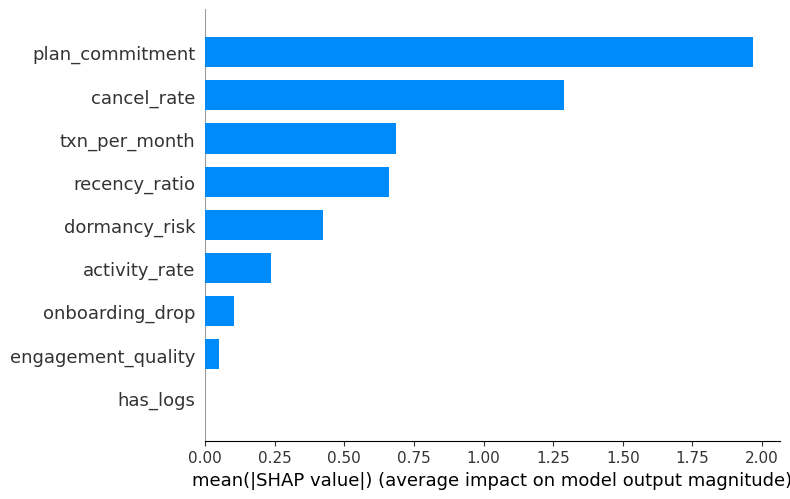

In [8]:
import shap

explainer = shap.TreeExplainer(model)

X_sample = X_test.sample(5000, random_state=42)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, plot_type="bar")

## SHAP beeswarm — direction and magnitude per subscriber

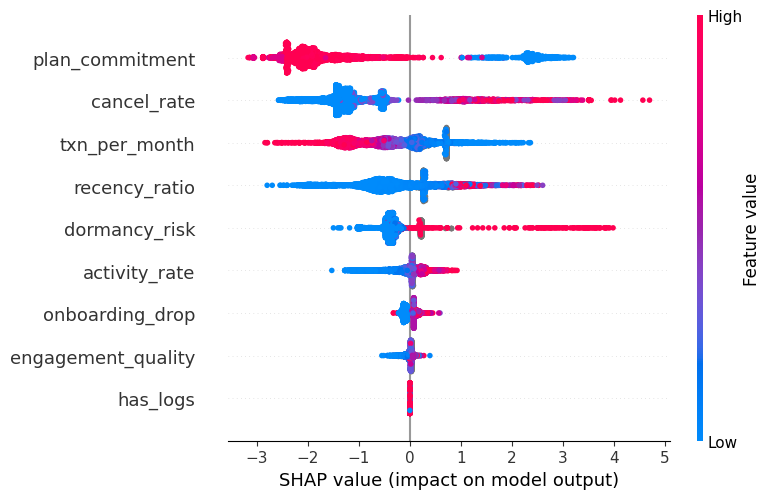

In [9]:
shap.summary_plot(shap_values, X_sample)

## Score all 1,082,190 subscribers and save

In [10]:
master_fe['churn_probability'] = model.predict_proba(X)[:, 1]

output_cols = ['msno', 'is_churn', 'churn_probability']
scored = master_fe[output_cols].copy()

scored.to_csv(PROCESSED / "master_scored.csv", index=False)

verify = pd.read_csv(PROCESSED / "master_scored.csv")
print(f"Saved: {verify.shape[0]:,} rows × {verify.shape[1]} columns")
print(f"\nScore distribution:")
print(scored['churn_probability'].describe().round(4))
print(f"\nHigh risk (>0.7): {(scored['churn_probability'] > 0.7).sum():,} subscribers")
print(f"Medium risk (0.3–0.7): {scored['churn_probability'].between(0.3, 0.7).sum():,} subscribers")
print(f"Low risk (<0.3): {(scored['churn_probability'] < 0.3).sum():,} subscribers")

Saved: 1,082,190 rows × 3 columns

Score distribution:
count    1.082190e+06
mean     1.878000e-01
std      3.182000e-01
min      5.000000e-04
25%      7.400000e-03
50%      1.920000e-02
75%      1.112000e-01
max      9.999000e-01
Name: churn_probability, dtype: float64

High risk (>0.7): 145,143 subscribers
Medium risk (0.3–0.7): 79,935 subscribers
Low risk (<0.3): 857,112 subscribers


## Conclusion

AUC 0.973 on held-out test data — above the 0.80–0.90 industry benchmark for churn models.

SHAP reveals churn is primarily a billing commitment problem. Plan type and auto-renewal status outweigh all engagement metrics combined. A subscriber without a long auto-renewing plan is at high risk regardless of how much they listen.

Output: `master_scored.csv` — 1,082,190 subscribers each with a churn probability.

Next: notebook 7 translates these probabilities into revenue impact.